## Diagnóstico de Câncer de Mama com Machine Learning

**Dataset:** Breast Cancer Wisconsin (Diagnostic)  
**Objetivo:** Classificar tumores como **Maligno (M)** ou **Benigno (B)** a partir de características extraídas de imagens de citologia por aspiração por agulha fina (FNA).

---

### Problema
O câncer de mama é uma das principais causas de mortalidade feminina no mundo. A detecção precoce aumenta significativamente as chances de cura. Este projeto constrói modelos de ML capazes de apoiar médicos na triagem de diagnósticos, classificando células como malignas ou benignas com base em características morfológicas do núcleo celular.

> **Importante:** O modelo serve como suporte à decisão. O médico deve sempre ter a palavra final no diagnóstico.

---
## 1. Importação de Bibliotecas

| Biblioteca | Uso neste projeto |
|---|---|
| `pandas` | Carregamento, manipulação e exploração do dataset |
| `numpy` | Operações numéricas auxiliares |
| `matplotlib` | Geração de gráficos base (heatmap, barras de importância) |
| `seaborn` | Visualização estatística de alto nível |
| `shap` | Explicabilidade dos modelos — valores SHAP para interpretar o impacto de cada feature |
| `sklearn.svm.SVC` | Modelo Support Vector Classifier para classificação |
| `sklearn.linear_model.LinearRegression` | Modelo de regressão linear usada para classificação |
| `sklearn.linear_model.LogisticRegression` | Modelo de regressão logística para classificação |
| `sklearn.tree.DecisionTreeClassifier` | Modelo de árvore de decisão para classificação |
| `sklearn.neighbors.KNeighborsClassifier` | Modelo KNN para classificação |
| `sklearn.model_selection.train_test_split` | Divisão dos dados em conjuntos de treino e teste |
| `sklearn.metrics` | Métricas de avaliação: acurácia, recall, precisão, F1 e relatório completo |
| `sklearn.inspection.permutation_importance` | Cálculo da importância de features por permutação (usado no SVC) |

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from pandas.plotting import scatter_matrix
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.linear_model import (LinearRegression, LogisticRegression)
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, precision_score,
    classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier


---
## 2. Carregamento e visualização inicial dos dados

Visualização simples da base para visualização inicial da estrutura da nossa base, como colunas, tipos de dados, valores.

In [336]:
# mostra todas as colunas
pd.set_option('display.max_columns', None)
dados = pd.read_csv("data.csv")
dados.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [337]:
dados.shape

(569, 33)

In [338]:
dados.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.256,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,0.3857,1.428,2.548,19.15,0.007189,0.00466,0.00000,0.00000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [339]:
print('\n--- Tipos de dados ---')
dados.info()


--- Tipos de dados ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  pe

In [340]:
dados.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'radius_mean'}>,
        <Axes: title={'center': 'texture_mean'}>,
        <Axes: title={'center': 'perimeter_mean'}>,
        <Axes: title={'center': 'area_mean'}>,
        <Axes: title={'center': 'smoothness_mean'}>],
       [<Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'concavity_mean'}>,
        <Axes: title={'center': 'concave points_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'fractal_dimension_mean'}>,
        <Axes: title={'center': 'radius_se'}>],
       [<Axes: title={'center': 'texture_se'}>,
        <Axes: title={'center': 'perimeter_se'}>,
        <Axes: title={'center': 'area_se'}>,
        <Axes: title={'center': 'smoothness_se'}>,
        <Axes: title={'center': 'compactness_se'}>,
        <Axes: title={'center': 'concavity_se'}>],
       [<Axes: title={'center': 'concave points_se'}>,
        <Axes: title={'center': 's

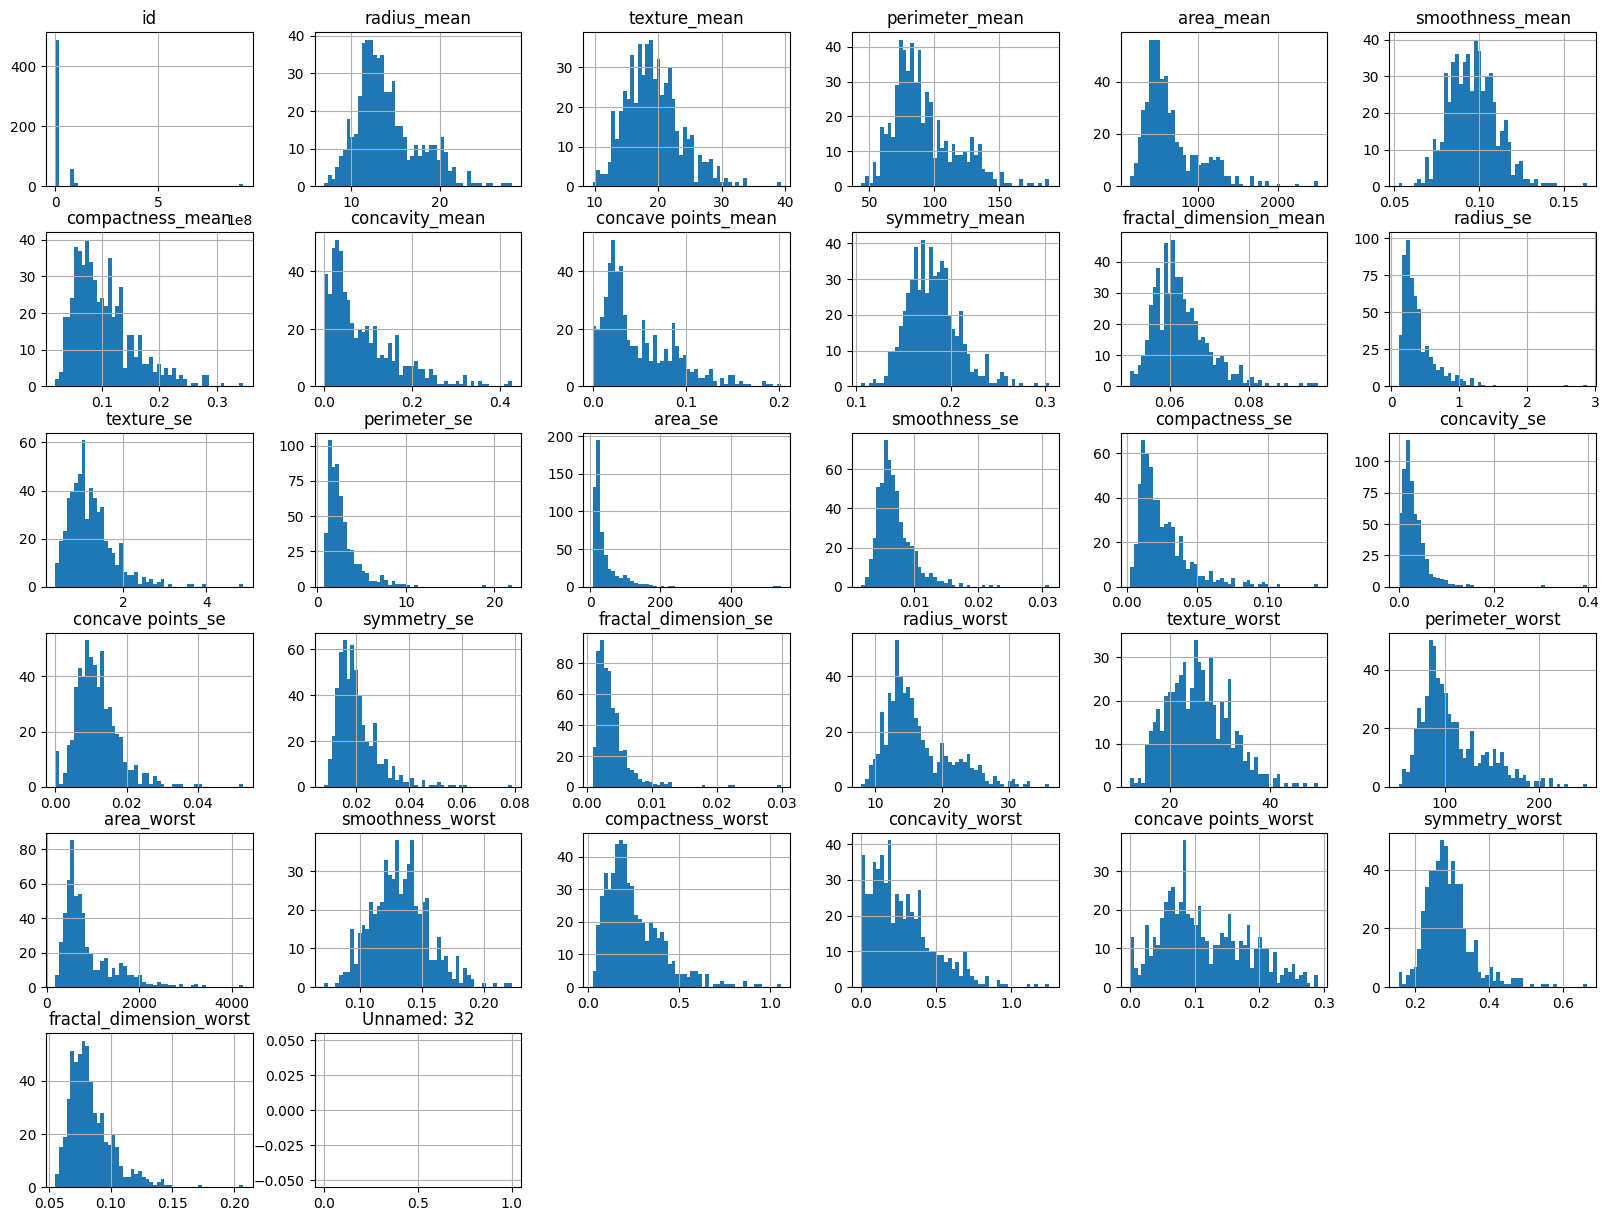

In [341]:
dados.hist(bins=50, figsize=(20, 15))

---
## 3. Pre-processamento e preparação dos dados

In [342]:
# Convertendo a coluna "diagnosis" para valores numéricos 1 e 0
# 1 para "M" (maligno) e 0 para "B" (benigno)
dados["diagnosis"] = dados["diagnosis"].map({"M": 1, "B": 0})
dados.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,1,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.256,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,1,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,1,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,1,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,0,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,0.3857,1.428,2.548,19.15,0.007189,0.00466,0.00000,0.00000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


Limpeza de dados repetidos e valores nulos para evitar conflitos e erros nos nossos modelos.

In [343]:
# Testamos remover mais colunas para ver se a acurácia do modelo melhora, 
# mas o resultado foi pior, então decidimos manter as colunas originais
#cols_to_drop = dados.columns[dados.columns.str.endswith("_mean") | dados.columns.str.endswith("_worst")| dados.columns.str.startswith("smoothness")| dados.columns.str.startswith("fractal")| dados.columns.str.startswith("texture")| dados.columns.str.startswith("symmetry_se")]

# removendo as colunas id e Unnamed: 32 para evitar confusão no modelo
# id nao tem relacao com o diagnostico, e Unnamed: 32 não tem valores relevantes
dados_parciais = dados.drop(["id", "Unnamed: 32"], axis=1)

# remover linhas com valores nulos
original_shape = dados_parciais.shape
dados_parciais = dados_parciais.dropna().drop_duplicates()

# remover linhas nulas
nulos = dados_parciais.isnull().sum()
nulos_total = nulos.sum()
duplicadas = dados_parciais.duplicated().sum()

print(f"Linhas originais: {original_shape[0]}")
print(f"Linhas após limpeza: {dados_parciais.shape[0]}")
print(f"Total de linhas removidas: {original_shape[0] - dados_parciais.shape[0]}")
print(f"Total de valores nulos: {nulos_total}")
print(f"Total de linhas duplicadas restantes: {duplicadas}")


Linhas originais: 569
Linhas após limpeza: 569
Total de linhas removidas: 0
Total de valores nulos: 0
Total de linhas duplicadas restantes: 0


In [344]:
correlacao = dados_parciais.corr()
correlacao

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,-0.012838,0.567134,-0.008303,0.556141,0.548236,-0.067016,0.292999,0.253730,0.408042,-0.006522,0.077972,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,0.679090,-0.097317,0.674172,0.735864,-0.222600,0.206000,0.194204,0.376169,-0.104321,-0.042641,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,0.275869,0.386358,0.281673,0.259845,0.006614,0.191975,0.143293,0.163851,0.009127,0.054458,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,0.691765,-0.086761,0.693135,0.744983,-0.202694,0.250744,0.228082,0.407217,-0.081629,-0.005523,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,0.732562,-0.066280,0.726628,0.800086,-0.166777,0.212583,0.207660,0.372320,-0.072497,-0.019887,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,0.301467,0.068406,0.296092,0.246552,0.332375,0.318943,0.248396,0.380676,0.200774,0.283607,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,0.497473,0.046205,0.548905,0.455653,0.135299,0.738722,0.570517,0.642262,0.229977,0.507318,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,0.631925,0.076218,0.660391,0.617427,0.098564,0.670279,0.691270,0.683260,0.178009,0.449301,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,0.698050,0.021480,0.710650,0.690299,0.027653,0.490424,0.439167,0.615634,0.095351,0.257584,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,0.303379,0.128053,0.313893,0.223970,0.187321,0.421659,0.342627,0.393298,0.449137,0.331786,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


In [345]:
correlacao['diagnosis'].sort_values(ascending=False)

diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

array([[<Axes: xlabel='diagnosis', ylabel='diagnosis'>,
        <Axes: xlabel='concave points_worst', ylabel='diagnosis'>,
        <Axes: xlabel='perimeter_worst', ylabel='diagnosis'>,
        <Axes: xlabel='concave points_mean', ylabel='diagnosis'>,
        <Axes: xlabel='radius_worst', ylabel='diagnosis'>,
        <Axes: xlabel='perimeter_mean', ylabel='diagnosis'>,
        <Axes: xlabel='area_worst', ylabel='diagnosis'>,
        <Axes: xlabel='radius_mean', ylabel='diagnosis'>,
        <Axes: xlabel='area_mean', ylabel='diagnosis'>],
       [<Axes: xlabel='diagnosis', ylabel='concave points_worst'>,
        <Axes: xlabel='concave points_worst', ylabel='concave points_worst'>,
        <Axes: xlabel='perimeter_worst', ylabel='concave points_worst'>,
        <Axes: xlabel='concave points_mean', ylabel='concave points_worst'>,
        <Axes: xlabel='radius_worst', ylabel='concave points_worst'>,
        <Axes: xlabel='perimeter_mean', ylabel='concave points_worst'>,
        <Axes: xlabe

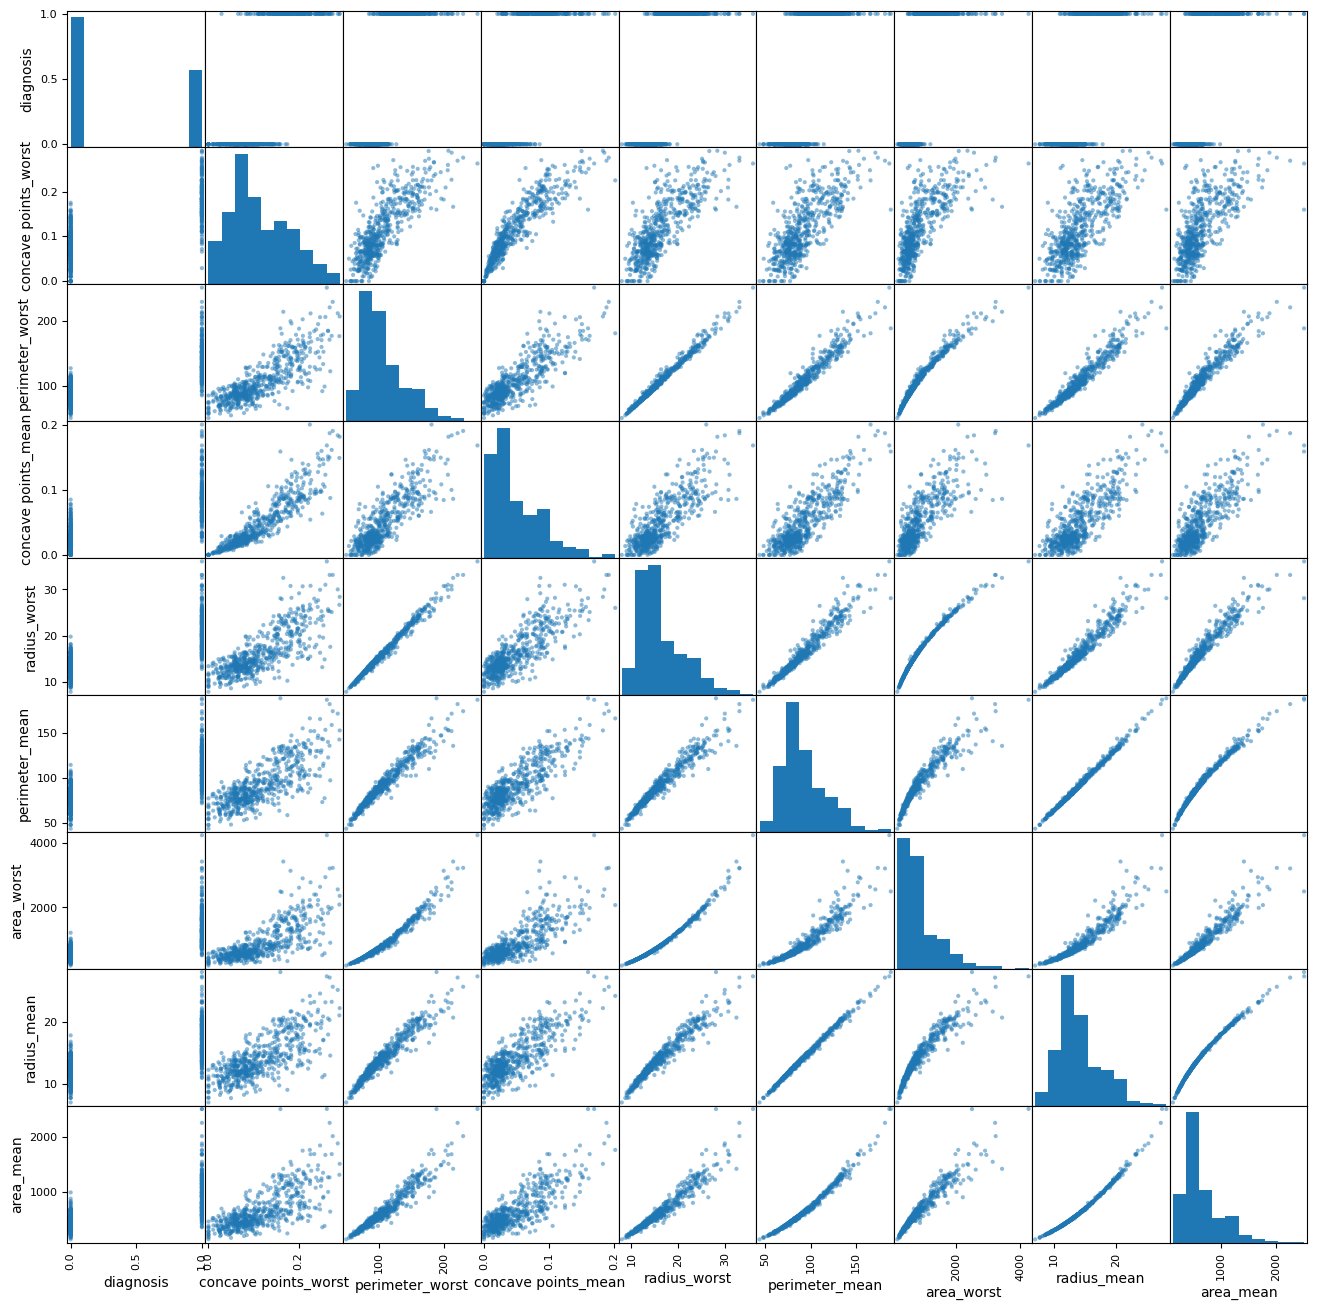

In [370]:
correlacao_subset = correlacao['diagnosis'].abs().sort_values(ascending=False)
attributes = correlacao_subset[correlacao_subset > 0.7].index.tolist()

scatter_matrix(dados_parciais[attributes], figsize=(16, 16))

Plotando as features com correlação > que 0.70 em um gráfico scatter para análise mais detalhada.
É possível notar que existe uma forte correlação linear do diagnóstico com as features analisádas.

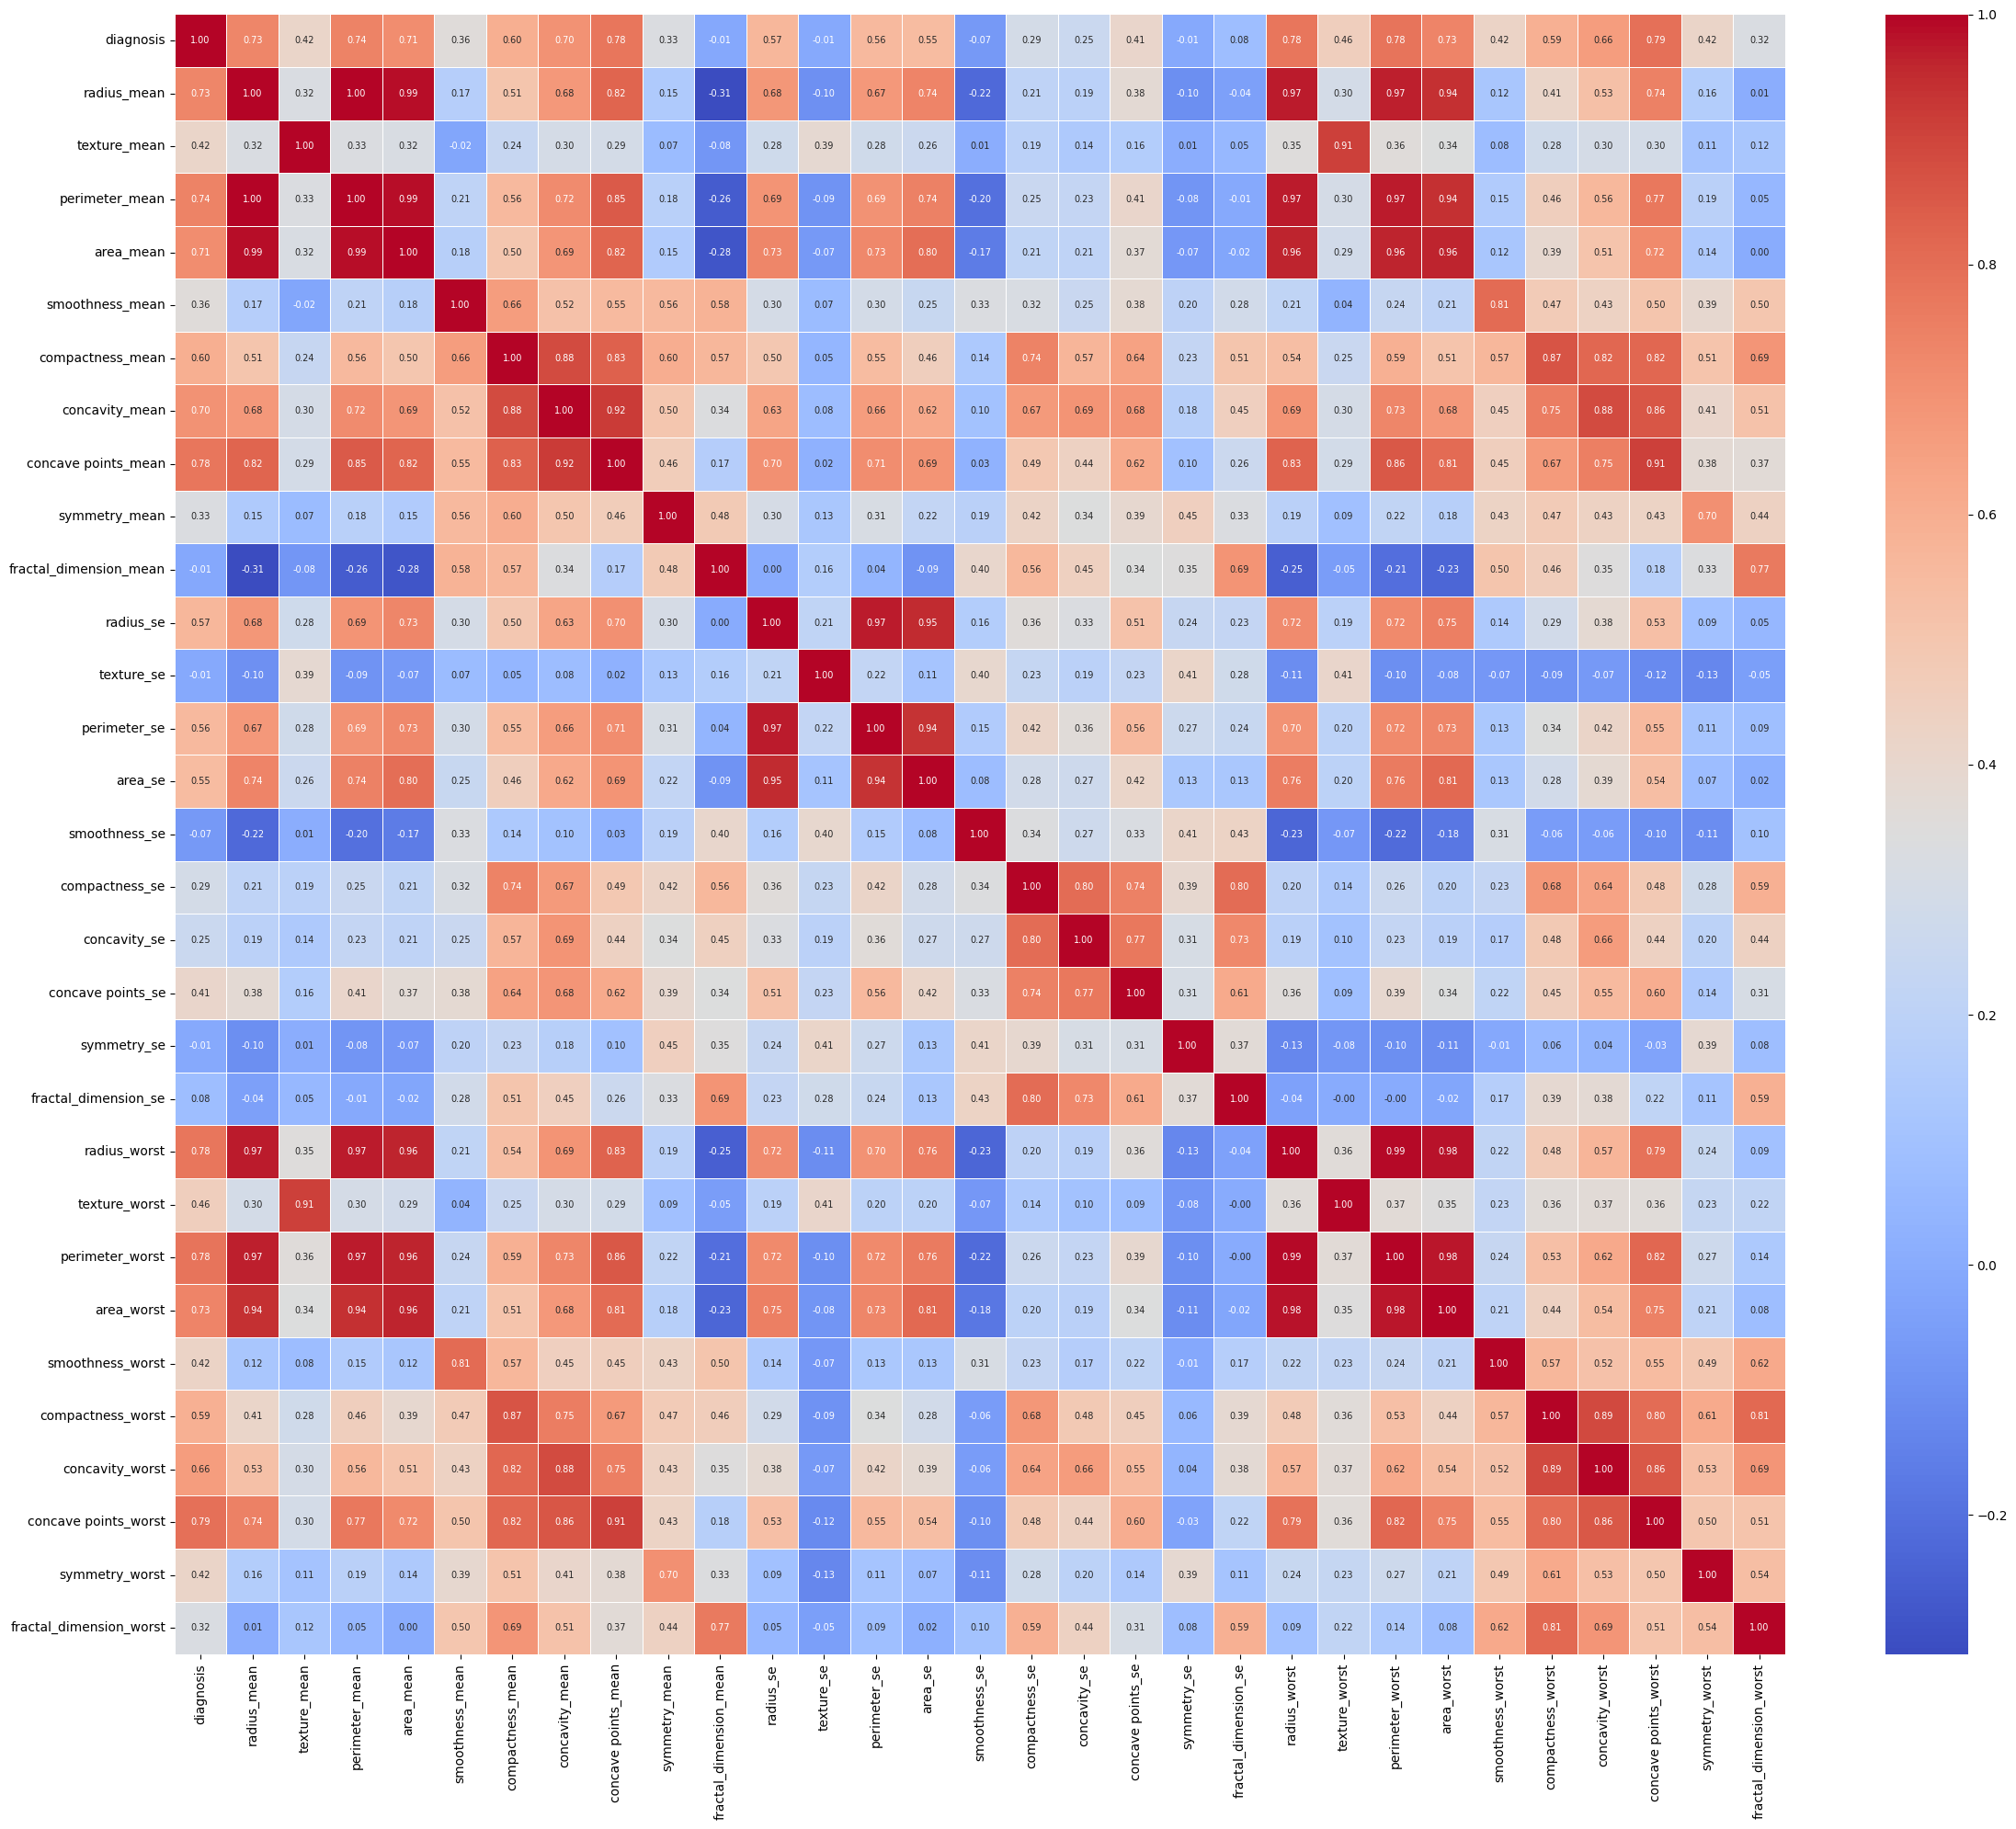

In [347]:
# Visualizando a matriz de correlação usando um heatmap
plt.figure(figsize=(24, 20))
sns.heatmap(correlacao, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 7}, linewidths=0.5)
plt.tight_layout()
plt.show()

In [348]:
# Preparando os dados para o modelo
X = dados_parciais.drop(columns=["diagnosis"]) # matriz (varias colunas) - sempre maiúsculo
y = dados_parciais.diagnosis # linear (1 coluna) - sempre minúsculo

In [ ]:
# Instanciando o pca e a quantidade de componentes que desejamos obter
pca = PCA(n_components=2)
# Aplicando PCA nas nossas features
principalComponents = pca.fit_transform(X)

/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


In [350]:
# Criando um novo dataframe para visualizarmos como ficou nossos dados reduzidos com o PCA
df_pca = pd.DataFrame(data = principalComponents,
                  columns = ['PC1', 'PC2'])

target = pd.Series(dados_parciais['diagnosis'], name='target')
result_df = pd.concat([df_pca, target], axis=1)
result_df

,PC1,PC2,target
0,1160.142574,-293.917544,1
1,1269.122443,15.630182,1
2,995.793889,39.156743,1
3,-407.180803,-67.380320,1
4,930.341180,189.340742,1
...,...,...,...
564,1414.126684,110.222492,1
565,1045.018854,77.057589,1
566,314.501756,47.553525,1
567,1124.858115,34.129225,1


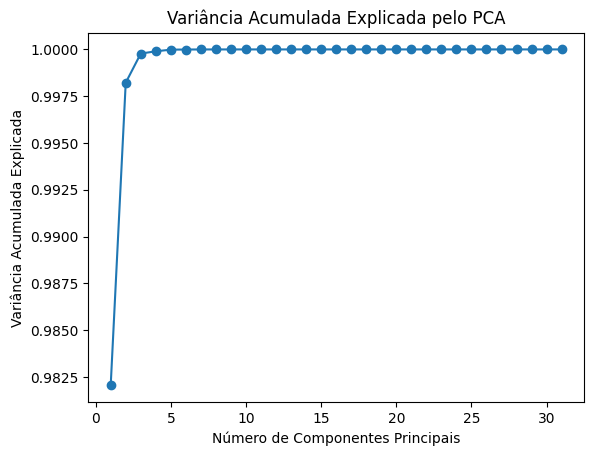

In [363]:
# Calcula a variância explicada acumulada
pca = PCA()
pca.fit(dados_parciais)
variancia_cumulativa = np.cumsum(pca.explained_variance_ratio_)
# Visualização da variância explicada acumulada
plt.plot(range(1, len(variancia_cumulativa) + 1), variancia_cumulativa, marker='o')
plt.xlabel('Número de Componentes Principais')
plt.ylabel('Variância Acumulada Explicada')
plt.title('Variância Acumulada Explicada pelo PCA')
plt.show()

In [364]:
# Vamos definir um limiar de 80%, ou seja, queremos obter uma porcentagem de explicancia sobre
# nossos dados de igual a 80%
limiar_de_variancia = 0.80

# Encontrar o número de componentes necessários para atingir ou ultrapassar o limiar
num_de_pca = np.argmax(variancia_cumulativa >= limiar_de_variancia) + 1

print(f"Número de Componentes para {limiar_de_variancia * 100}% da Variância: {num_de_pca}")

Número de Componentes para 80.0% da Variância: 1


In [351]:
# Divisão treino/teste (80/20) sem estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [352]:
# Visualizando dados de treino
X_train

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
68,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,0.08046,0.3274,1.1940,1.8850,17.67,0.009549,0.086060,0.303800,0.033220,0.04197,0.009559,10.310,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750
181,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,0.07398,0.6298,0.7629,4.4140,81.46,0.004253,0.047590,0.038720,0.015670,0.01798,0.005295,26.680,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,0.02180,0.2341,0.06963,0.4098,2.2650,2.6080,23.52,0.008738,0.039380,0.043120,0.015600,0.04192,0.005822,10.010,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490
248,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,0.01615,0.1897,0.06329,0.2497,1.4930,1.4970,16.64,0.007189,0.010350,0.010810,0.006245,0.02158,0.002619,12.250,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147
60,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,0.5158,1.4410,3.3120,34.62,0.007514,0.010990,0.007665,0.008193,0.04183,0.005953,11.020,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,8.888,14.64,58.79,244.0,0.09783,0.15310,0.08606,0.02872,0.1902,0.08980,0.5262,0.8522,3.1680,25.44,0.017210,0.093680,0.056710,0.017660,0.02541,0.021930,9.733,15.67,62.56,284.4,0.12070,0.24360,0.14340,0.04786,0.2254,0.10840
106,11.640,18.33,75.17,412.5,0.11420,0.10170,0.07070,0.03485,0.1801,0.06520,0.3060,1.6570,2.1550,20.62,0.008540,0.023100,0.029450,0.013980,0.01565,0.003840,13.140,29.26,85.51,521.7,0.16880,0.26600,0.28730,0.12180,0.2806,0.09097
270,14.290,16.82,90.30,632.6,0.06429,0.02675,0.00725,0.00625,0.1508,0.05376,0.1302,0.7198,0.8439,10.77,0.003492,0.003710,0.004826,0.003608,0.01536,0.001381,14.910,20.65,94.44,684.6,0.08567,0.05036,0.03866,0.03333,0.2458,0.06120
435,13.980,19.62,91.12,599.5,0.10600,0.11330,0.11260,0.06463,0.1669,0.06544,0.2208,0.9533,1.6020,18.85,0.005314,0.017910,0.021850,0.009567,0.01223,0.002846,17.040,30.80,113.90,869.3,0.16130,0.35680,0.40690,0.18270,0.3179,0.10550


---
## 4. Treinando os modelos

In [353]:
results = {}

#model = SVC(kernel="rbf", C=1.0, gamma="scale")
model = SVC(kernel="linear", C=2, class_weight={0:1, 1:5})

# =========================
# 4.1. Treinar
# =========================
model.fit(X_train, y_train)

# =========================
# 4.2. Prever
# =========================
y_pred = model.predict(X_test)

# =========================
# 4.3. Avaliar
# =========================
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório:\n", classification_report(y_test, y_pred))

results["SVC Linear"] = {
    'accuracy': accuracy_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
}

Acurácia: 0.9385964912280702

Relatório:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95        71
           1       0.88      0.98      0.92        43

    accuracy                           0.94       114
   macro avg       0.93      0.95      0.94       114
weighted avg       0.94      0.94      0.94       114



Um detalhe para salientar aqui é que foi testado o SVC com o kernel RBF e o resultado não foi interessante como foi com o modelo linear, dessa forma o modelo linear foi mantido.

Relatório de resultado com modelo o kernel RBF: 

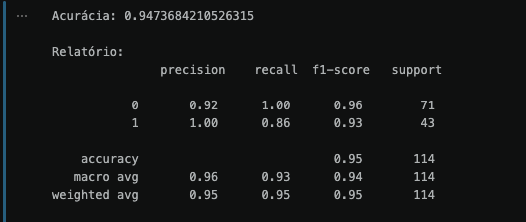

É possível visualizarmos que a acurácia melhorou porém o recall para o positivo piorou, o que não é aceitável para o nosso cenário.

In [354]:
for i in range(10):
    entrada = X_test.iloc[i:i+1]
    real = y_test.iloc[i]
    pred = model.predict(entrada)[0]

    print(f"Real: {real} | Pred: {pred}")

Real: 0 | Pred: 0
Real: 1 | Pred: 1
Real: 1 | Pred: 1
Real: 0 | Pred: 0
Real: 0 | Pred: 0
Real: 1 | Pred: 1
Real: 1 | Pred: 1
Real: 1 | Pred: 1
Real: 0 | Pred: 0
Real: 0 | Pred: 0


In [355]:
model_1 = LinearRegression()

# =========================
# 4.4. Treinar
# =========================
model_1.fit(X_train, y_train)

# =========================
# 4.5. Prever
# =========================
# TODO: O predict desse modelo está causando warnings de divisão por zero e number overflow
y_pred_1 = model_1.predict(X_test)
y_pred_1_classes = (y_pred_1 >= 0.5).astype(int)

# =========================
# 4.6. Avaliar
# =========================
print("Acurácia:", accuracy_score(y_test, y_pred_1_classes))
print("Relatório:", classification_report(y_test, y_pred_1_classes))

results["Linear Regression"] = {
    'accuracy': accuracy_score(y_test, y_pred_1_classes),
    'recall': recall_score(y_test, y_pred_1_classes),
    'precision': precision_score(y_test, y_pred_1_classes),
    'f1': f1_score(y_test, y_pred_1_classes),
}

Acurácia: 0.956140350877193
Relatório:               precision    recall  f1-score   support

           0       0.95      0.99      0.97        71
           1       0.97      0.91      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [356]:
model_2 = DecisionTreeClassifier(max_depth=5, random_state=42)

# =========================
# 4.7. Treinar
# =========================
model_2.fit(X_train, y_train)

# =========================
# 4.8. Prever
# =========================
y_pred_2 = model_2.predict(X_test)

# =========================
# 4.9. Avaliar
# =========================
print('Acuracia:', accuracy_score(y_test, y_pred_2))
print('Relatorio:', classification_report(y_test, y_pred_2))

results['Decision Tree'] = {
    'accuracy': accuracy_score(y_test, y_pred_2),
    'recall': recall_score(y_test, y_pred_2),
    'precision': precision_score(y_test, y_pred_2),
    'f1': f1_score(y_test, y_pred_2),
}


Acuracia: 0.9473684210526315
Relatorio:               precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [357]:
model_3 = LogisticRegression(max_iter=10000, random_state=42, class_weight={0:1, 1:5})

# =========================
# 4.10. Treinar
# =========================
model_3.fit(X_train, y_train)

# =========================
# 4.11. Prever
# =========================
y_pred_3 = model_3.predict(X_test)

# =========================
# 4.12. Avaliar
# =========================
print('Acuracia:', accuracy_score(y_test, y_pred_3))
print('Relatorio:', classification_report(y_test, y_pred_3))

results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_3),
    'recall': recall_score(y_test, y_pred_3),
    'precision': precision_score(y_test, y_pred_3),
    'f1': f1_score(y_test, y_pred_3),
}

/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountered in matmul
  grad[:

Acuracia: 0.9736842105263158
Relatorio:               precision    recall  f1-score   support

           0       0.99      0.97      0.98        71
           1       0.95      0.98      0.97        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pedroguerreiro/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [358]:
model_4 = KNeighborsClassifier(n_neighbors=5)

# =========================
# 4.13. Treinar
# =========================
model_4.fit(X_train, y_train)

# =========================
# 4.14. Prever
# =========================
y_pred_4 = model_4.predict(X_test)

# =========================
# 4.15. Avaliar
# =========================
print('Acuracia:', accuracy_score(y_test, y_pred_4))
print('Relatorio:', classification_report(y_test, y_pred_4))

results['KNN'] = {
    'accuracy': accuracy_score(y_test, y_pred_4),
    'recall': recall_score(y_test, y_pred_4),
    'precision': precision_score(y_test, y_pred_4),
    'f1': f1_score(y_test, y_pred_4),
}

Acuracia: 0.956140350877193
Relatorio:               precision    recall  f1-score   support

           0       0.93      1.00      0.97        71
           1       1.00      0.88      0.94        43

    accuracy                           0.96       114
   macro avg       0.97      0.94      0.95       114
weighted avg       0.96      0.96      0.96       114



---
## 5. Comparação de resultado dos modelos

In [359]:
metrics_df = pd.DataFrame([
    {
        'Modelo': name,
        'Acurácia': f"{v['accuracy']:.4f}",
        'Recall': f"{v['recall']:.4f}",
        'Precisão': f"{v['precision']:.4f}",
        'F1-Score': f"{v['f1']:.4f}",
    }
    for name, v in results.items()
])
metrics_df

,Modelo,Acurácia,Recall,Precisão,F1-Score
0,SVC Linear,0.9386,0.9767,0.8750,0.9231
1,Linear Regression,0.9561,0.9070,0.9750,0.9398
2,Decision Tree,0.9474,0.9302,0.9302,0.9302
3,Logistic Regression,0.9737,0.9767,0.9545,0.9655
4,KNN,0.9561,0.8837,1.0000,0.9383


Analisando os resultados podemos ver que o modelo de Regressão Logística oferece o melhor Recall entre os modelos, assim como o SVC Linear, porém o SVC oferece menos acurácia e precisão.

Dessa forma entendemos que o Regressão Logística seria o modelo ideal. Porém para chegarmos nesse resultado nós testamos o peso do caso positivo no modelo, alterando o peso do target maligno (1) partindo de 1 até 5. 
No exemplo abaixo o peso do caso positivo foi configurado em 3: 

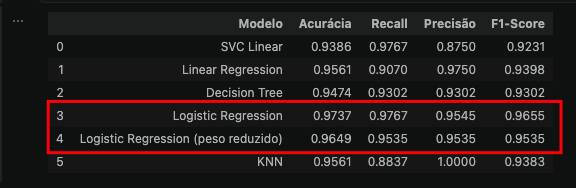

Podemos ver como o modelo perdeu acurácia e o recall também foi afetado.

Testamos também com um peso maior e vemos que também houve um declínio na precisão e acurácia apesar do recall se manter o mesmo: 

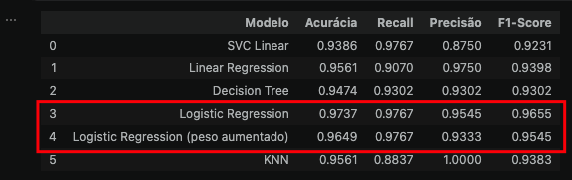

Dessa forma entendemos que o peso 5 seria o ideal para este modelo.

---
## 6. Visualização das decisões dos modelos

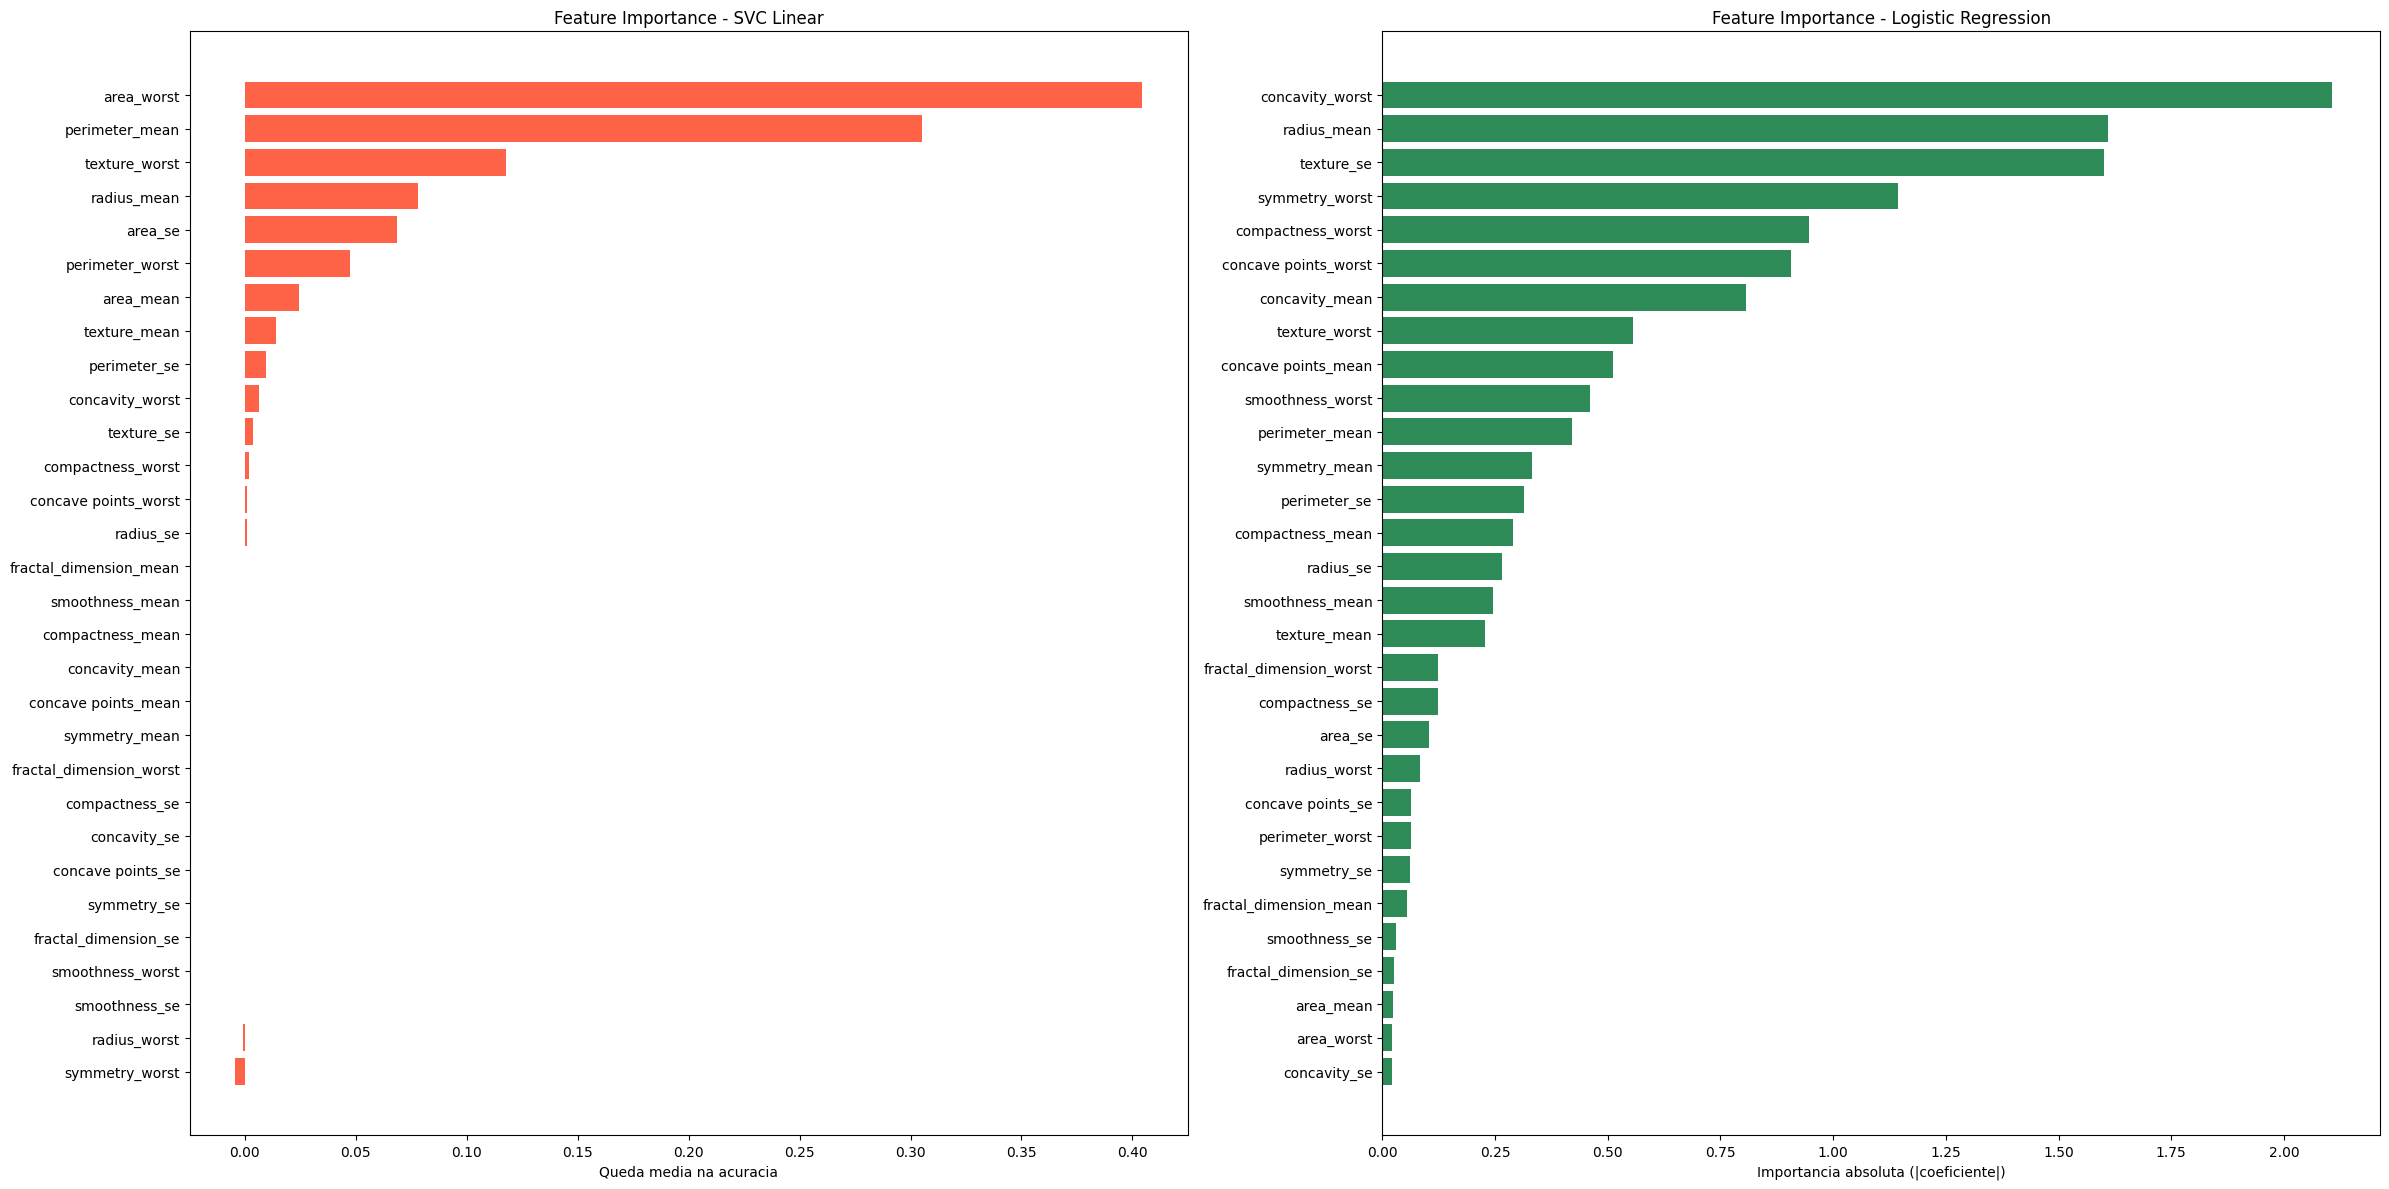

In [377]:
feature_names = X_train.columns.tolist()

# LogisticRegression: coeficientes como importância
log_importance = np.abs(model_3.coef_[0])
log_order = np.argsort(log_importance)[::-1]

# SVC (Linear): permutation importance
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
svc_importance = perm.importances_mean
svc_order = np.argsort(svc_importance)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(24, 12))

axes[0].barh(
    [feature_names[i] for i in svc_order],
    svc_importance[svc_order],
    color="tomato"
)
axes[0].invert_yaxis()
axes[0].set_title("Feature Importance - SVC Linear")
axes[0].set_xlabel("Queda media na acuracia")

axes[1].barh(
    [feature_names[i] for i in log_order],
    log_importance[log_order],
    color="seagreen"
)
axes[1].invert_yaxis()
axes[1].set_title("Feature Importance - Logistic Regression")
axes[1].set_xlabel("Importancia absoluta (|coeficiente|)")

plt.tight_layout()
plt.show()

=== SHAP - Logistic Regression ===


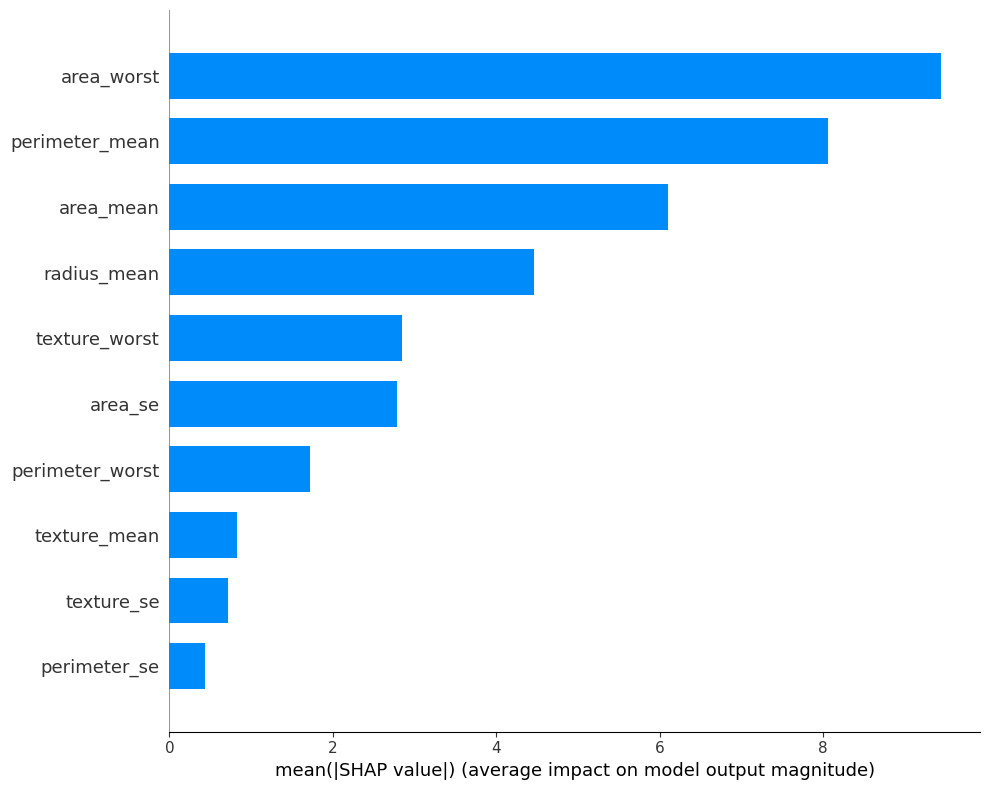

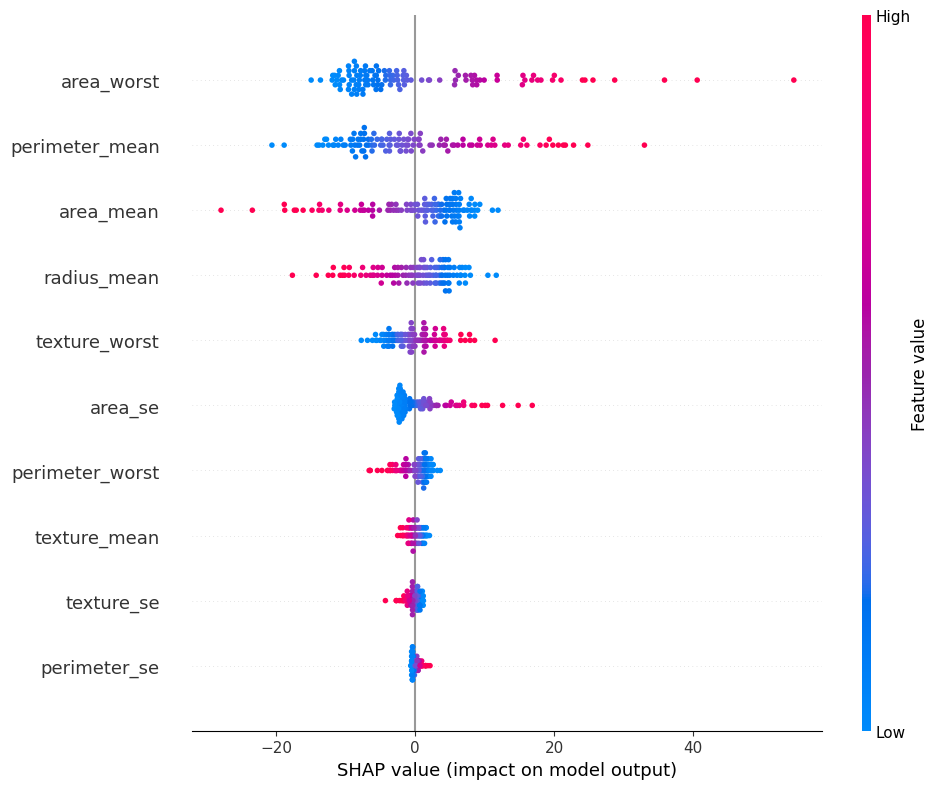

In [378]:
# SHAP - Logistic Regression
log_explainer = shap.LinearExplainer(model_3, X_train)
log_shap_values = log_explainer.shap_values(X_test)

print("=== SHAP - Logistic Regression ===")
shap.summary_plot(log_shap_values, X_test, plot_type="bar", title="SHAP - Logistic Regression (importancia media)", max_display=10, plot_size=(10,8))
shap.summary_plot(log_shap_values, X_test, title="SHAP - Logistic Regression (impacto por amostra)", max_display=10, plot_size=(10,8))

---
## 7. Análise dos resultados

In [ ]:
print("Foi possível analisar que o modelo de Regressão Logística alcançou os melhores resultados.")
print(
    f"Com uma acurácia de {results['Logistic Regression']['accuracy']:.4f}, "
    f"recall de {results['Logistic Regression']['recall']:.4f}, "
    "o modelo de Regressão Logística se destacou em comparação aos outros modelos testados."
)
print(
    f"Apesar do modelo KNN apresentar uma precisão ótima de {results['KNN']['precision']:.4f}, sua acurácia foi um pouco inferior e o recall foi um pouco alarmante, "
      "indicando que ele teve mais dificuldade em identificar corretamente os casos positivos (malignos) em comparação à Regressão Logística."
      "E esse resultado é algo que pode induzir e enviesar a análise humana, levando a uma decisão que pode ser prejudicial para o paciente, como um falso negativo (diagnóstico de benigno quando é maligno).")


Foi possível analisar que o modelo de Regressão Logística alcançou os melhores resultados.
Com uma acurácia de 0.9737, recall de 0.9767, o modelo de Regressão Logística se destacou em comparação aos outros modelos testados.
Apesar do modelo KNN apresentar uma precisão ótima de 1.0000, sua acurácia foi um pouco inferiore recall foi um pouco alarmante, indicando que ele teve mais dificuldade em identificar corretamente os casos positivos (malignos) em comparação à Regressão Logística.E esse resultado é algo que pode induzir e enviesar a análise humana, levando a uma decisão que pode ser prejudicial para o paciente, como um falso negativo (diagnóstico de benigno quando é maligno).
